In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone

import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv("./아마도최종데이터.csv")
df.head()

,Date,brent_close,wti_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_ma_5,brent_ma_20,brent_ma_60,brent_vol_5d,high_low_range,crude_stock_level,gas_stock_level,dist_stock_level,crude_stock_wow_change,gas_stock_wow_change,dist_stock_wow_change,crude_stock_vs_5yr_avg,gas_stock_vs_5yr_avg,dist_stock_vs_5yr_avg,prod_weekly,prod_4w_ma,prod_wow_change,crude_exports,crude_imports,import_4w_ma,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,XLE_XLE,VDE_VDE,IXC_IXC,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",us10y_yield,us2y_yield,term_spread,bdi_price,bdi_open,bdi_high,bdi_low,bdi_change_%,wti_mm_net_long_is_update,wti_mm_net_long_shock_raw,wti_mm_net_long_days_since_update,wti_mm_net_long_avail,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_is_update,wti_mm_net_long_ratio_shock_raw,wti_mm_net_long_ratio_days_since_update,wti_mm_net_long_ratio_avail,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_is_update,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_days_since_update,wti_producer_hedge_ratio_avail,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_is_update,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_days_since_update,wti_mm_position_change_wow_avail,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_is_update,wti_sentiment_position_shock_raw,wti_sentiment_position_days_since_update,wti_sentiment_position_avail,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,crude_vs5_zscore,news_total_count,clust_0_count,clust_1_count,clust_2_count,clust_3_count,clust_4_count,clust_5_count,clust_6_count,clust_7_count,clust_8_count,clust_9_count,clust_10_count,clust_11_count,clust_12_count,clust_13_count,clust_14_count,clust_15_count,clust_16_count,clust_17_count,clust_18_count,clust_19_count,clust_20_count,clust_21_count,clust_22_count,clust_23_count,clust_24_count,clust_25_count,clust_26_count,clust_27_count,clust_28_count,clust_29_count,clust_0_impact_mean,clust_1_impact_mean,clust_2_impact_mean,clust_3_impact_mean,clust_4_impact_mean,clust_5_impact_mean,clust_6_impact_mean,clust_7_impact_mean,clust_8_impact_mean,clust_9_impact_mean,clust_10_impact_mean,clust_11_impact_mean,clust_12_impact_mean,clust_13_impact_mean,clust_14_impact_mean,clust_15_impact_mean,clust_16_impact_mean,clust_17_impact_mean,clust_18_impact_mean,clust_19_impact_mean,clust_20_impact_mean,clust_21_impact_mean,clust_22_impact_mean,clust_23_impact_mean,clust_24_impact_mean,clust_25_impact_mean,clust_26_impact_mean,clust_27_impact_mean,clust_28_impact_mean,clust_29_impact_mean,clust_0_impact_sum,clust_1_impact_sum,clust_2_impact_sum,clust_3_impact_sum,clust_4_impact_sum,clust_5_impact_sum,clust_6_impact_sum,clust_7_impact_sum,clust_8_impact_sum,clust_9_impact_sum,clust_10_impact_sum,clust_11_impact_sum,clust_12_impact_sum,clust_13_impact_sum,clust_14_impact_sum,clust_15_impact_sum,clust_16_impact_sum,clust_17_impact_sum,clust_18_impact_sum,clust_19_impact_sum,clust_20_impact_sum,clust_21_impact_sum,clust_22_impact_sum,clust_23_impact_sum,clust_24_impact_sum,clust_25_impact_sum,clust_26_impact_sum,clust_27_impact_sum,clust_28_impact_sum,clust_29_impact_sum,news_emb_0,news_emb_1,news_emb_2,news_emb_3,news_emb_4,news_emb_5,news_emb_6,news_emb_7,news_emb_8,news_emb_9,news_emb_10,news_emb_11,news_emb_12,news_emb_13,news_emb_14,news_emb_15,news_emb_16,news_emb_17,news_emb_18,news_emb_19,news_emb_20,news_emb_21,news_emb_22,news_emb_23,news_emb_24,news_emb_25,news_emb_26,news_emb_27,news_emb_28,news_emb_29,news_emb_30,news_emb_31,news_emb_32,news_emb_33,news_emb_34,news_emb

In [4]:
df.keys()

Index(['Date', 'brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d', 'brent_ret_20d', 'brent_ma_5', 'brent_ma_20',
       'brent_ma_60',
       ...
       'news_emb_55', 'news_emb_56', 'news_emb_57', 'news_emb_58',
       'news_emb_59', 'news_emb_60', 'news_emb_61', 'news_emb_62',
       'news_emb_63', 'news_uuids'],
      dtype='object', length=245)

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

cols = [
    'brent_close',
    'wti_close',
    'brent_wti_spread',
    'brent_ret_1d',
    'brent_ret_5d',
    'brent_ret_20d',
    'brent_ma_5',
    'brent_ma_20',
    'brent_ma_60',
    'brent_vol_5d',
]

# 피처 subset
df_sub = df[cols].dropna().copy()

# VIF 계산용 DataFrame
vif_df = pd.DataFrame()
vif_df["feature"] = df_sub.columns
vif_df["VIF"] = [
    variance_inflation_factor(df_sub.values, i)
    for i in range(df_sub.shape[1])
]

vif_df


,feature,VIF
0,brent_close,inf
1,wti_close,inf
2,brent_wti_spread,inf
3,brent_ret_1d,1.892039
4,brent_ret_5d,2.781424
5,brent_ret_20d,3.571526
6,brent_ma_5,3737.074235
7,brent_ma_20,2373.786506
8,brent_ma_60,399.787908
9,brent_vol_5d,2.520799


In [6]:
df_final = pd.read_csv("./아마도최종데이터.csv")
df_final = df_final.sort_index()

# 타깃: 다음 날 Brent 종가
df_model = df_final.copy()
df_model["target_ret_1d"] = (df_model["brent_close"].shift(-1) / df_model["brent_close"]) - 1

In [7]:
df_lag = df_model.copy()
target_col = "target_ret_1d"


# lag를 줄 컬럼들 (예시)
lag_cols = []

# 1) 마켓/펀더멘탈 피처 중에서 일부
lag_cols += [
    "brent_ret_1d", "brent_ret_5d", "brent_vol_5d",
    "crude_stock_vs_5yr_avg", "spread_regime_code", "crude_vs5_regime_code",
    "news_total_count"
]

# 2) 뉴스 클러스터 impact_sum 계열
lag_cols += [c for c in df_lag.columns if "clust_" in c and c.endswith("_impact_sum")]

# 3) 뉴스 임베딩 (64차원) – 이건 lag 1만 먼저
lag_cols += [c for c in df_lag.columns if c.startswith("news_emb_")]

lag_cols = list(dict.fromkeys(lag_cols))  # 중복 제거

# lag 생성 함수
def add_lag_features(df, columns, lags=[1]):
    for col in columns:
        if col not in df.columns:
            continue
        for L in lags:
            df[f"{col}_lag{L}"] = df[col].shift(L)
    return df

# 일단 lag 1만 먼저 테스트
df_lag = add_lag_features(df_lag, lag_cols, lags=[1])

# 타깃 NaN, lag로 인해 생긴 앞부분 NaN 날리기
df_lag = df_lag.dropna(subset=[target_col]).copy()


In [8]:
drop_cols = [
    target_col,
    "spread_regime",
    "crude_vs5_regime",
    "news_uuids",
]

drop_cols = [c for c in drop_cols if c in df_lag.columns]

feature_cols = [c for c in df_lag.columns if c not in drop_cols]

X = df_lag[feature_cols].copy()
y = df_lag[target_col].copy()

non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("비수치형 피처 제거:", non_numeric)
    X = X.drop(columns=non_numeric)
    feature_cols = X.columns.tolist()

비수치형 피처 제거: ['Date']


In [9]:
X.drop('news_uuids', axis=1, inplace=True, errors='ignore')

In [10]:
# 타깃 shift(-1) 때문에 마지막 날이 NaN, 
# 초반부에 일부 파생변수 NaN 있을 수 있어서 통째로 dropna
data = pd.concat([X, y], axis=1).dropna()

X = data[feature_cols]
y = data[target_col]


In [11]:
def train_test_split_time_series(
    X, y, test_size_ratio=0.2, normalize_columns=True
):
    # 1) 컬럼명 정규화
    if normalize_columns:
        X = X.copy()
        X.columns = [
            re.sub(r'[^A-Za-z0-9_]+', '_', col)
            for col in X.columns
        ]
    
    # 2) 시계열 분할
    n = len(X)
    test_size = int(n * test_size_ratio)
    train_size = n - test_size

    X_train = X.iloc[:train_size].copy()
    y_train = y.iloc[:train_size].copy()
    X_test  = X.iloc[train_size:].copy()
    y_test  = y.iloc[train_size:].copy()

    return X_train, X_test, y_train, y_test


# 사용
X_train, X_test, y_train, y_test = train_test_split_time_series(X, y)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Sample columns:", X_train.columns[:5])


Train size: (2387, 342) Test size: (596, 342)
Sample columns: Index(['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d',
       'brent_ret_5d'],
      dtype='object')


In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# RandomForest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# GradientBoosting
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# LightGBM
lgbm = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.015,
    max_depth=-1,       # Leaf-wise best
    num_leaves=63,      # 적절한 leaf 수
    subsample=0.8,      # bagging
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# CatBoost
cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49230
[LightGBM] [Info] Number of data points in the train set: 2387, number of used features: 333
[LightGBM] [Info] Start training from score 0.000186


In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


# # 이건 타겟이 종가일때
def directional_accuracy_price(y_true, y_pred):
    """
    y_true, y_pred: '내일 종가'(price) 시계열
    방향성 = 어제 대비 내일이 오르냐/내리냐를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # 길이 체크
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    # 어제 종가 (t-1)
    prev_true = np.roll(y_true, 1)
    prev_true[0] = np.nan  # 첫 값은 기준 없음

    true_dir = np.sign(y_true - prev_true)   # 실제 방향
    pred_dir = np.sign(y_pred - prev_true)   # 예측 방향

    # NaN 제거 + 변화 없는 날(0) 제거
    mask = ~np.isnan(prev_true) & (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()

# 이건 타겟이 수익률일때
def directional_accuracy_return(y_true, y_pred):
    """
    y_true, y_pred: '내일 수익률'(return)
    방향성 = 수익률 부호(sign)를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)

    mask = (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, target_type="return"):
    # 예측
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    
    # RMSE (직접 sqrt)
    mse_tr  = mean_squared_error(y_tr, pred_tr)
    mse_te  = mean_squared_error(y_te, pred_te)
    rmse_tr = np.sqrt(mse_tr)
    rmse_te = np.sqrt(mse_te)

    # MAE
    mae_tr  = mean_absolute_error(y_tr, pred_tr)
    mae_te  = mean_absolute_error(y_te, pred_te)


    # 방향성
    if target_type == "price":
        dir_tr = directional_accuracy_price(y_tr, pred_tr)
        dir_te = directional_accuracy_price(y_te, pred_te)
    else:  # "return"
        dir_tr = directional_accuracy_return(y_tr, pred_tr)
        dir_te = directional_accuracy_return(y_te, pred_te)
    
    print(f"\n[{name}]")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_te, mae_te, dir_te
    ))
    
    return {
        "pred_train": pred_tr,
        "pred_test": pred_te,
    }


In [14]:
# 타깃이 내일 수익률이면 (예: brent_ret_1d_next)
rf_res   = evaluate_model("RandomForest",       rf,   X_train, y_train, X_test, y_test,
                          target_type="price")
gb_res   = evaluate_model("GradientBoosting",   gb,   X_train, y_train, X_test, y_test,
                          target_type="price")
lgbm_res = evaluate_model("LightGBM",           lgbm, X_train, y_train, X_test, y_test,
                          target_type="price")
cat_res  = evaluate_model("CatBoost",           cat,  X_train, y_train, X_test, y_test,
                          target_type="price")



[RandomForest]
Train - RMSE: 0.0220, MAE: 0.0159, DirAcc: 0.764
Test  - RMSE: 0.0409, MAE: 0.0360, DirAcc: 0.571

[GradientBoosting]
Train - RMSE: 0.0160, MAE: 0.0121, DirAcc: 0.821
Test  - RMSE: 0.0380, MAE: 0.0332, DirAcc: 0.576

[LightGBM]
Train - RMSE: 0.0058, MAE: 0.0020, DirAcc: 0.987
Test  - RMSE: 0.0381, MAE: 0.0334, DirAcc: 0.575

[CatBoost]
Train - RMSE: 0.0120, MAE: 0.0091, DirAcc: 0.876
Test  - RMSE: 0.0247, MAE: 0.0200, DirAcc: 0.637


In [15]:
def evaluate_as_price_from_return(
    name,
    y_ret_tr, y_ret_te,        # y_train, y_test (수익률 타깃)
    pred_ret_tr, pred_ret_te,  # 모델 예측 수익률
    price_series               # df_model["brent_close"]
):
    """
    y_ret_* : (t 시점 기준) '내일 수익률' 시계열
    price_series : 전체 brent_close 시계열 (df_model["brent_close"])
    """
    # 인덱스 기준으로 today / next price 정렬
    price_today_tr = price_series.loc[y_ret_tr.index]              # P_t
    price_today_te = price_series.loc[y_ret_te.index]              # P_t

    true_price_next_tr = price_series.shift(-1).loc[y_ret_tr.index]  # P_{t+1}
    true_price_next_te = price_series.shift(-1).loc[y_ret_te.index]  # P_{t+1}

    # 예측한 '내일 종가' = 오늘 종가 * (1 + 예측 수익률)
    pred_price_tr = price_today_tr * (1.0 + pred_ret_tr)
    pred_price_te = price_today_te * (1.0 + pred_ret_te)

    # RMSE / MAE (가격 기준)
    rmse_tr = np.sqrt(mean_squared_error(true_price_next_tr, pred_price_tr))
    rmse_te = np.sqrt(mean_squared_error(true_price_next_te, pred_price_te))

    mae_tr = mean_absolute_error(true_price_next_tr, pred_price_tr)
    mae_te = mean_absolute_error(true_price_next_te, pred_price_te)

    # MAPE (가격 기준)
    mape_tr = calc_mape(true_price_next_tr, pred_price_tr)
    mape_te = calc_mape(true_price_next_te, pred_price_te)

    # 방향성: 사실 수익률 부호랑 동일하므로 기존 함수 재사용 가능
    dir_tr = directional_accuracy_return(y_ret_tr, pred_ret_tr)
    dir_te = directional_accuracy_return(y_ret_te, pred_ret_te)

    print(f"\n[Price Eval from Return] {name}")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, mape_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_te, mae_te, mape_te, dir_te
    ))

    return {
        "true_price_train": true_price_next_tr,
        "true_price_test":  true_price_next_te,
        "pred_price_train": pred_price_tr,
        "pred_price_test":  pred_price_te,
    }


# 1) 수익률 기준 평가 (기존 함수 그대로 사용)
rf_res   = evaluate_model("RandomForest",     rf,   X_train, y_train, X_test, y_test,
                          target_type="return")
gb_res   = evaluate_model("GradientBoosting", gb,   X_train, y_train, X_test, y_test,
                          target_type="return")
lgbm_res = evaluate_model("LightGBM",         lgbm, X_train, y_train, X_test, y_test,
                          target_type="return")
cat_res  = evaluate_model("CatBoost",         cat,  X_train, y_train, X_test, y_test,
                          target_type="return")


# 2) 가격 기준 평가 (수익률 → 가격 변환)
price_series = df_model["brent_close"]  # 인덱스가 y_train / y_test랑 같다고 가정

rf_price_eval = evaluate_as_price_from_return(
    "RandomForest",
    y_train, y_test,
    rf_res["pred_train"], rf_res["pred_test"],
    price_series,
)

gb_price_eval = evaluate_as_price_from_return(
    "GradientBoosting",
    y_train, y_test,
    gb_res["pred_train"], gb_res["pred_test"],
    price_series,
)

lgbm_price_eval = evaluate_as_price_from_return(
    "LightGBM",
    y_train, y_test,
    lgbm_res["pred_train"], lgbm_res["pred_test"],
    price_series,
)

cat_price_eval = evaluate_as_price_from_return(
    "CatBoost",
    y_train, y_test,
    cat_res["pred_train"], cat_res["pred_test"],
    price_series,
)



[RandomForest]
Train - RMSE: 0.0220, MAE: 0.0159, DirAcc: 0.606
Test  - RMSE: 0.0409, MAE: 0.0360, DirAcc: 0.502

[GradientBoosting]
Train - RMSE: 0.0160, MAE: 0.0121, DirAcc: 0.765
Test  - RMSE: 0.0380, MAE: 0.0332, DirAcc: 0.508

[LightGBM]
Train - RMSE: 0.0058, MAE: 0.0020, DirAcc: 0.979
Test  - RMSE: 0.0381, MAE: 0.0334, DirAcc: 0.505

[CatBoost]
Train - RMSE: 0.0120, MAE: 0.0091, DirAcc: 0.865
Test  - RMSE: 0.0247, MAE: 0.0200, DirAcc: 0.513

[Price Eval from Return] RandomForest
Train - RMSE: 1.4723, MAE: 1.0272, MAPE: 1.60%, DirAcc: 0.606
Test  - RMSE: 3.1188, MAE: 2.7361, MAPE: 3.58%, DirAcc: 0.502

[Price Eval from Return] GradientBoosting
Train - RMSE: 1.0743, MAE: 0.7886, MAPE: 1.21%, DirAcc: 0.765
Test  - RMSE: 2.8735, MAE: 2.5112, MAPE: 3.30%, DirAcc: 0.508

[Price Eval from Return] LightGBM
Train - RMSE: 0.2864, MAE: 0.1137, MAPE: 0.20%, DirAcc: 0.979
Test  - RMSE: 2.8710, MAE: 2.5282, MAPE: 3.32%, DirAcc: 0.505

[Price Eval from Return] CatBoost
Train - RMSE: 0.8142, MA

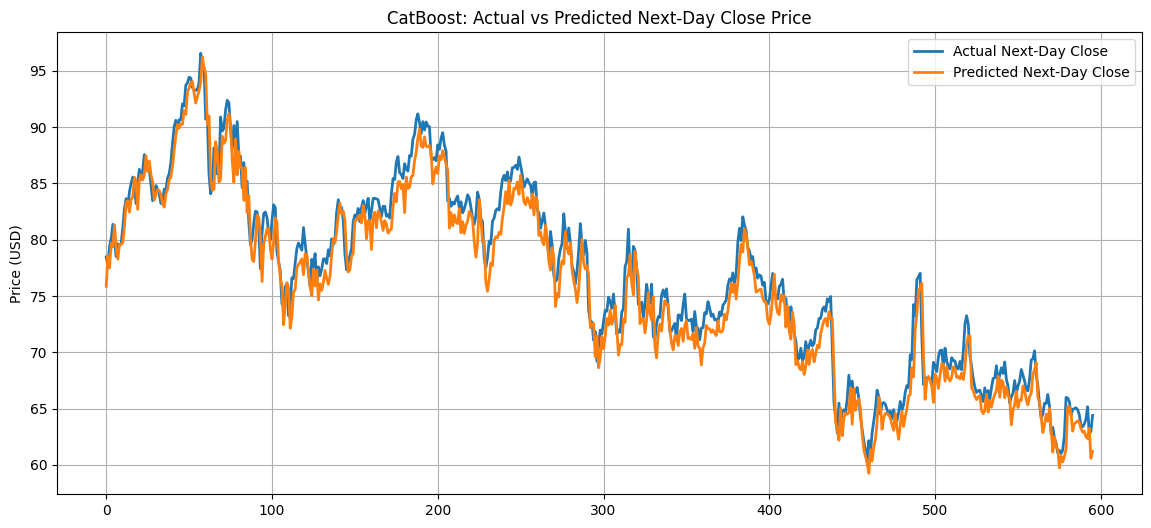

In [16]:
# 1) 오늘 종가
close_today = df_model.loc[y_test.index, "brent_close"]

# 2) 내일 종가 복원 (ret 정의는 target_ret_1d = (close_next/close_today)-1 인 걸로 가정)
y_pred_cat = cat.predict(X_test)

actual_close_next = close_today * (1 + y_test.values)
pred_close_next   = close_today * (1 + y_pred_cat)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(actual_close_next.values, label="Actual Next-Day Close", linewidth=2)
plt.plot(pred_close_next.values,  label="Predicted Next-Day Close", linewidth=2)
plt.title("CatBoost: Actual vs Predicted Next-Day Close Price")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.show()

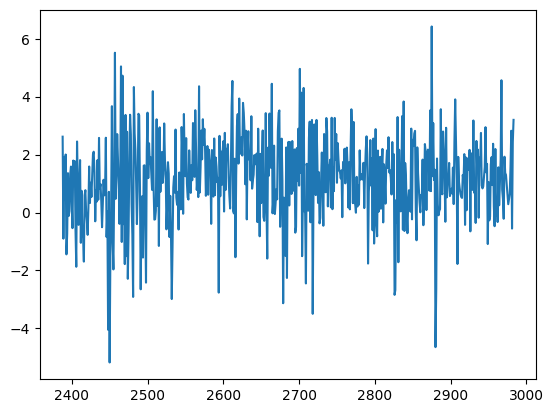

In [17]:
residual_price = actual_close_next - pred_close_next
plt.plot(residual_price)


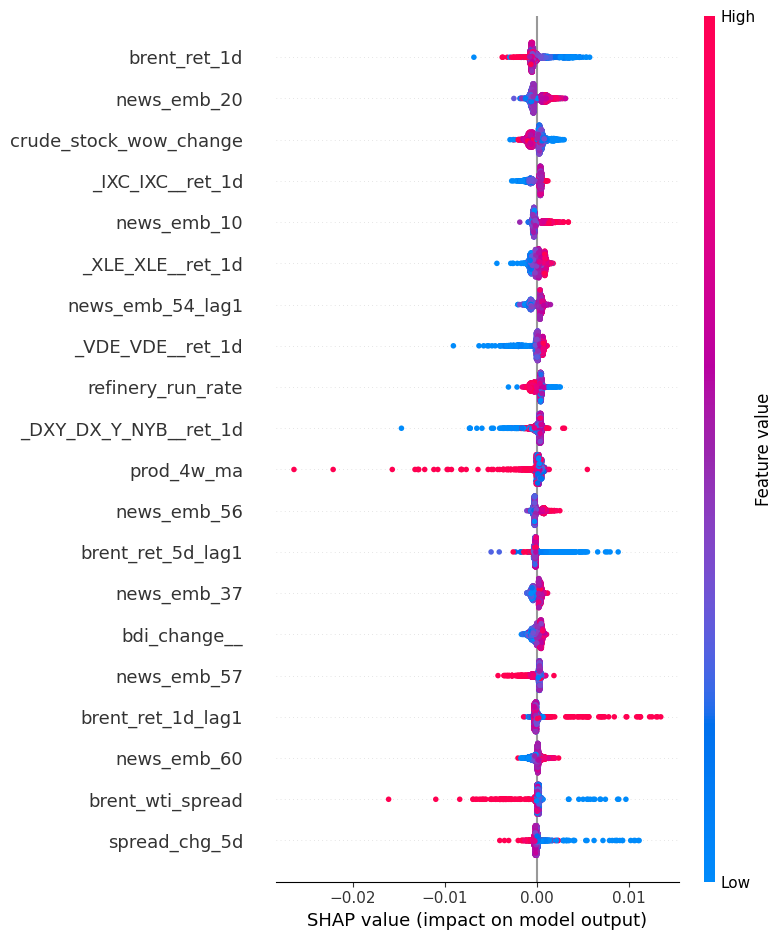

                    feature  mean_abs_shap
3              brent_ret_1d       0.000794
197             news_emb_20       0.000661
14   crude_stock_wow_change       0.000624
40         _IXC_IXC__ret_1d       0.000522
187             news_emb_10       0.000509
38         _XLE_XLE__ret_1d       0.000508
332        news_emb_54_lag1       0.000504
39         _VDE_VDE__ret_1d       0.000449
27        refinery_run_rate       0.000436
37    _DXY_DX_Y_NYB__ret_1d       0.000425
21               prod_4w_ma       0.000399
233             news_emb_56       0.000395
242       brent_ret_5d_lag1       0.000384
214             news_emb_37       0.000373
48             bdi_change__       0.000363
234             news_emb_57       0.000356
241       brent_ret_1d_lag1       0.000333
237             news_emb_60       0.000317
2          brent_wti_spread       0.000297
82            spread_chg_5d       0.000282


In [18]:
import shap

# 1) SHAP 초기화 (한 번만)
#   - CatBoostRegressor는 바로 TreeExplainer로 넣어도 됩니다.
explainer = shap.TreeExplainer(cat)

# 2) SHAP 값 계산 (train 기준)
shap_values = explainer.shap_values(X_train)

# 3) summary plot (주요 피처 직관적으로 보기)
shap.summary_plot(shap_values, X_train, max_display=20)

# 4) mean(|SHAP|) 기준으로 중요도 테이블 만들기
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(20))


In [19]:
# target / 날짜 / 식별자 등은 제외
target_col = "target_ret_1d"

drop_cols = [
    target_col,
    # 날짜/인덱스 계열 컬럼 있으면 여기 추가
    "date", "period", "datetime",
    # 혹시 있다면 id 같은 것들
    # "id",
]

feature_cols = [c for c in df_model.columns if c not in drop_cols]
print("피처 개수:", len(feature_cols))
print(feature_cols[:20])


피처 개수: 245
['Date', 'brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d', 'brent_ret_5d', 'brent_ret_20d', 'brent_ma_5', 'brent_ma_20', 'brent_ma_60', 'brent_vol_5d', 'high_low_range', 'crude_stock_level', 'gas_stock_level', 'dist_stock_level', 'crude_stock_wow_change', 'gas_stock_wow_change', 'dist_stock_wow_change', 'crude_stock_vs_5yr_avg', 'gas_stock_vs_5yr_avg']


In [20]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df, cols):
    """
    df: DataFrame (보통 train 데이터)
    cols: 피처 컬럼 리스트
    """
    X = df[cols].astype(float).values
    vif_list = []

    for i, col in enumerate(cols):
        vif = variance_inflation_factor(X, i)
        vif_list.append((col, vif))

    vif_df = pd.DataFrame(vif_list, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
    return vif_df


In [21]:
# train 인덱스 기준
df_train = df_model.loc[X_train.index]

# feature_cols 안에서 숫자가 아닌 컬럼들 확인
non_num_cols = df_train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print("비수치 컬럼들:", non_num_cols)


비수치 컬럼들: ['Date', 'spread_regime', 'crude_vs5_regime', 'news_uuids']


In [22]:
# VIF 계산에 쓸 숫자형 피처만 선택
feature_cols_num = df_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print("VIF 계산용 숫자 피처 개수:", len(feature_cols_num))
print(feature_cols_num[:20])


VIF 계산용 숫자 피처 개수: 241
['brent_close', 'wti_close', 'brent_wti_spread', 'brent_ret_1d', 'brent_ret_5d', 'brent_ret_20d', 'brent_ma_5', 'brent_ma_20', 'brent_ma_60', 'brent_vol_5d', 'high_low_range', 'crude_stock_level', 'gas_stock_level', 'dist_stock_level', 'crude_stock_wow_change', 'gas_stock_wow_change', 'dist_stock_wow_change', 'crude_stock_vs_5yr_avg', 'gas_stock_vs_5yr_avg', 'dist_stock_vs_5yr_avg']


In [23]:
vif_df = compute_vif(df_train, feature_cols_num)
vif_df

,feature,VIF
0,brent_close,inf
1,wti_close,inf
2,brent_wti_spread,inf
16,dist_stock_wow_change,inf
12,gas_stock_level,inf
13,dist_stock_level,inf
15,gas_stock_wow_change,inf
19,dist_stock_vs_5yr_avg,inf
18,gas_stock_vs_5yr_avg,inf
42,us2y_yield,inf


In [24]:
# 느슨한 기준: VIF <= 10
feature_vif10 = vif_df[vif_df["VIF"] <= 10]["feature"].tolist()

# 보통 기준: VIF <= 5
feature_vif5 = vif_df[vif_df["VIF"] <= 5]["feature"].tolist()

# 엄격한 기준: VIF <= 3
feature_vif3 = vif_df[vif_df["VIF"] <= 3]["feature"].tolist()

print("VIF<=10 피처 수:", len(feature_vif10))
print("VIF<=5  피처 수:", len(feature_vif5))
print("VIF<=3  피처 수:", len(feature_vif3))

VIF<=10 피처 수: 91
VIF<=5  피처 수: 86
VIF<=3  피처 수: 76


In [25]:
drop_linear = [
    "wti_close",
]
drop_linear += [
    "crude_imports",
    "crude_exports",
]
drop_linear += [
    "us10y_yield",
    "us2y_yield",
]
drop_linear += [
    "news_total_count",
]
# clust_*_impact_sum 전부 제거
drop_linear += [
    c for c in feature_cols_num
    if c.startswith("clust_") and c.endswith("_impact_sum")
]
drop_linear += [
    "bdi_open",
    "bdi_high",
    "bdi_low",
]


In [26]:
df_train = df_model.loc[X_train.index]

# 숫자 피처만
feature_cols_num = df_train.select_dtypes(include=[np.number]).columns.tolist()

drop_linear = []

# 1) 브렌트/WTI/스프레드
drop_linear += ["wti_close"]

# 2) 수입/수출/순수입
drop_linear += ["crude_imports", "crude_exports"]

# 3) 10y/2y/스프레드
drop_linear += ["us10y_yield", "us2y_yield"]

# 4) 뉴스 total vs cluster count
drop_linear += ["news_total_count"]  # cluster count는 일단 살려둠

# 5) 클러스터 impact_sum 제거
drop_linear += [
    c for c in feature_cols_num
    if c.startswith("clust_") and c.endswith("_impact_sum")
]

# 6) BDI OHLC 중복 제거
drop_linear += ["bdi_open", "bdi_high", "bdi_low"]

# 중복 제거
drop_linear = sorted(set([c for c in drop_linear if c in feature_cols_num]))
print("선형관계로 제거할 후보 피처 수:", len(drop_linear))
print(drop_linear)


선형관계로 제거할 후보 피처 수: 39
['bdi_high', 'bdi_low', 'bdi_open', 'clust_0_impact_sum', 'clust_10_impact_sum', 'clust_11_impact_sum', 'clust_12_impact_sum', 'clust_13_impact_sum', 'clust_14_impact_sum', 'clust_15_impact_sum', 'clust_16_impact_sum', 'clust_17_impact_sum', 'clust_18_impact_sum', 'clust_19_impact_sum', 'clust_1_impact_sum', 'clust_20_impact_sum', 'clust_21_impact_sum', 'clust_22_impact_sum', 'clust_23_impact_sum', 'clust_24_impact_sum', 'clust_25_impact_sum', 'clust_26_impact_sum', 'clust_27_impact_sum', 'clust_28_impact_sum', 'clust_29_impact_sum', 'clust_2_impact_sum', 'clust_3_impact_sum', 'clust_4_impact_sum', 'clust_5_impact_sum', 'clust_6_impact_sum', 'clust_7_impact_sum', 'clust_8_impact_sum', 'clust_9_impact_sum', 'crude_exports', 'crude_imports', 'news_total_count', 'us10y_yield', 'us2y_yield', 'wti_close']


In [27]:
feature_cols_num_reduced = [c for c in feature_cols_num if c not in drop_linear]

vif_df2 = compute_vif(df_train, feature_cols_num_reduced)
vif_df2.sort_values("VIF", ascending=False).head(50)

,feature,VIF
54,wti_producer_hedge_ratio_avail,inf
53,wti_producer_hedge_ratio_days_since_update,inf
51,wti_producer_hedge_ratio_is_update,inf
58,wti_mm_position_change_wow_days_since_update,inf
41,wti_mm_net_long_is_update,inf
17,gas_stock_vs_5yr_avg,inf
18,dist_stock_vs_5yr_avg,inf
15,dist_stock_wow_change,inf
14,gas_stock_wow_change,inf
12,dist_stock_level,inf


In [28]:
drop_linear += [
    c for c in feature_cols_num
    if ('days_since_update' in c) or ('is_update' in c) or ('avail' in c)
]


In [29]:
drop_linear += [
    "gas_stock_level", "dist_stock_level",
    "gas_stock_wow_change", "dist_stock_wow_change",
    "gas_stock_vs_5yr_avg", "dist_stock_vs_5yr_avg",
]


In [30]:
drop_linear += [
    c for c in feature_cols_num
    if c.startswith("clust_") and c.endswith("_count")
]


In [31]:
drop_linear = sorted(set([c for c in drop_linear if c in feature_cols_num]))


In [32]:
feature_cols_num_reduced = [c for c in feature_cols_num if c not in drop_linear]
vif_df2 = compute_vif(df_train, feature_cols_num_reduced)
vif_df2.sort_values("VIF", ascending=False).head(50)

,feature,VIF
12,crude_stock_vs_5yr_avg,31484.057263
56,crude_vs5_zscore,23344.028293
26,VDE_VDE,1201.575698
25,XLE_XLE,1122.919597
5,brent_ma_5,621.162967
0,brent_close,535.700636
27,IXC_IXC,327.489721
13,prod_weekly,301.411391
14,prod_4w_ma,294.612071
6,brent_ma_20,245.312519


In [33]:
drop_linear_2nd = []

# 1) crude 5yr avg vs zscore 중복 제거
drop_linear_2nd += ["crude_vs5_zscore"]  # vs5yr_avg는 유지할지 선택

# 2) ETF raw price 제거 (수익률만 유지)
etf_price_cols = ["XLE_XLE", "VDE_VDE", "IXC_IXC"]
drop_linear_2nd += etf_price_cols

# 3) Brent MA 제거
drop_linear_2nd += ["brent_ma_5", "brent_ma_20", "brent_ma_60"]

# 4) 생산량 raw vs MA 중복 제거
drop_linear_2nd += ["prod_4w_ma"]

# 5) COT shock 계열 중복 제거 (ratio/raw 중 하나만 선택)
drop_linear_2nd += [
    "wti_mm_net_long_shock_raw",
    "wti_mm_net_long_ratio_shock_raw"
]

# 6) sentiment raw vs shock 중복 제거
drop_linear_2nd += [
    "wti_sentiment_position_shock_raw"
]

# 7) 나머지 너무 큰 VIF 하나씩 제거
drop_linear_2nd += ["import_4w_ma", "term_spread"]


In [34]:
drop_all = sorted(set(drop_linear + drop_linear_2nd))

feature_cols_num_reduced = [
    c for c in feature_cols_num
    if c not in drop_all
]

vif_df3 = compute_vif(df_train, feature_cols_num_reduced)
vif_df3.sort_values("VIF", ascending=False).head(40)


,feature,VIF
13,refinery_run_rate,1410.512322
19,DXY_DX-Y.NYB,992.419427
10,prod_weekly,866.121738
7,crude_stock_level,509.646525
21,"('XLE', 'XLE')_ret_1d",164.516263
22,"('VDE', 'VDE')_ret_1d",153.646747
12,net_imports,91.899213
0,brent_close,41.138640
23,"('IXC', 'IXC')_ret_1d",26.638694
9,crude_stock_vs_5yr_avg,24.651743


In [35]:
drop_all

['IXC_IXC',
 'VDE_VDE',
 'XLE_XLE',
 'bdi_high',
 'bdi_low',
 'bdi_open',
 'brent_ma_20',
 'brent_ma_5',
 'brent_ma_60',
 'clust_0_count',
 'clust_0_impact_sum',
 'clust_10_count',
 'clust_10_impact_sum',
 'clust_11_count',
 'clust_11_impact_sum',
 'clust_12_count',
 'clust_12_impact_sum',
 'clust_13_count',
 'clust_13_impact_sum',
 'clust_14_count',
 'clust_14_impact_sum',
 'clust_15_count',
 'clust_15_impact_sum',
 'clust_16_count',
 'clust_16_impact_sum',
 'clust_17_count',
 'clust_17_impact_sum',
 'clust_18_count',
 'clust_18_impact_sum',
 'clust_19_count',
 'clust_19_impact_sum',
 'clust_1_count',
 'clust_1_impact_sum',
 'clust_20_count',
 'clust_20_impact_sum',
 'clust_21_count',
 'clust_21_impact_sum',
 'clust_22_count',
 'clust_22_impact_sum',
 'clust_23_count',
 'clust_23_impact_sum',
 'clust_24_count',
 'clust_24_impact_sum',
 'clust_25_count',
 'clust_25_impact_sum',
 'clust_26_count',
 'clust_26_impact_sum',
 'clust_27_count',
 'clust_27_impact_sum',
 'clust_28_count',
 'cl

In [36]:
import numpy as np

# 클러스터 count 컬럼들 추출
cluster_count_cols = [c for c in df_train.columns if c.startswith("clust_") and c.endswith("_count")]

# 가장 큰 count를 가진 클러스터 index 뽑기
df_train["dominant_cluster"] = df_train[cluster_count_cols].idxmax(axis=1)

# 이름에서 숫자만 추출 (clust_7_count → 7)
df_train["dominant_cluster"] = df_train["dominant_cluster"].str.extract(r"clust_(\d+)_count").astype(int)


In [37]:
cluster_impact_cols = [c for c in df_train.columns if c.startswith("clust_") and c.endswith("_impact_mean")]

df_train["impact_cluster"] = df_train[cluster_impact_cols].idxmax(axis=1)
df_train["impact_cluster"] = df_train["impact_cluster"].str.extract(r"clust_(\d+)_impact_mean").astype(int)


In [38]:
target = df_model[target_col]

corr_list = []
for col in feature_cols_num_reduced:
    c = df_model[col].corr(target)
    corr_list.append((col, c))

corr_df = (
    pd.DataFrame(corr_list, columns=["feature", "corr_with_target"])
    .assign(abs_corr=lambda x: x["corr_with_target"].abs())
    .sort_values("abs_corr", ascending=False)
)

corr_df.head(20)


,feature,corr_with_target,abs_corr
138,target_ret_1d,1.000000,1.000000
41,spread_chg_5d,-0.135544,0.135544
1,brent_wti_spread,-0.119551,0.119551
71,clust_27_impact_mean,-0.065798,0.065798
22,"('VDE', 'VDE')_ret_1d",0.056772,0.056772
6,high_low_range,0.054401,0.054401
23,"('IXC', 'IXC')_ret_1d",0.053935,0.053935
21,"('XLE', 'XLE')_ret_1d",0.052470,0.052470
0,brent_close,-0.048250,0.048250
134,news_emb_60,0.047827,0.047827


In [39]:
# 거의 무정보 (절대 상관 0.03 미만)
low_info_features = corr_df[corr_df["abs_corr"] < 0.03]["feature"].tolist()

# 후보: |corr| >= 0.1
feature_corr01 = corr_df[corr_df["abs_corr"] >= 0.10]["feature"].tolist()

# 강한 후보: |corr| >= 0.2
feature_corr02 = corr_df[corr_df["abs_corr"] >= 0.20]["feature"].tolist()

print("corr>=0.10 피처 수:", len(feature_corr01))
print("corr>=0.20 피처 수:", len(feature_corr02))
print("무정보 피처 수(|corr|<0.03):", len(low_info_features))


corr>=0.10 피처 수: 3
corr>=0.20 피처 수: 1
무정보 피처 수(|corr|<0.03): 112


In [40]:
cluster_count_cols = [c for c in df_model.columns 
                      if c.startswith("clust_") and c.endswith("_count")]

df_model["dominant_cluster"] = df_model[cluster_count_cols].idxmax(axis=1)
df_model["dominant_cluster"] = df_model["dominant_cluster"].str.extract(
    r"clust_(\d+)_count"
).astype(int)


cluster_impact_cols = [c for c in df_model.columns 
                       if c.startswith("clust_") and c.endswith("_impact_mean")]

df_model["impact_cluster"] = df_model[cluster_impact_cols].idxmax(axis=1)
df_model["impact_cluster"] = df_model["impact_cluster"].str.extract(
    r"clust_(\d+)_impact_mean"
).astype(int)


In [41]:
# ---------------------------
# 1) drop_all 삭제
# ---------------------------
df_final2 = df_model.drop(columns=drop_all, errors='ignore')

# ---------------------------
# 2) 클러스터 원핫 계열 제거
# ---------------------------
cluster_cols = [c for c in df_final2.columns 
                if c.startswith("clust_")]

# 대표 클러스터 컬럼은 제외시키기
cluster_cols = [
    c for c in cluster_cols 
    if c not in ["dominant_cluster", "impact_cluster"]
]

df_final2 = df_final2.drop(columns=cluster_cols, errors='ignore')

# ---------------------------
# 3) 최종 확인
# ---------------------------
print("삭제된 clust_* 피처 수:", len(cluster_cols))
print("삭제된 drop_all 피처 수:", len(drop_all))
print("최종 남은 피처 수:", df_final2.shape[1])

df_final2.head()


삭제된 clust_* 피처 수: 30
삭제된 drop_all 피처 수: 103
최종 남은 피처 수: 115


,Date,brent_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_vol_5d,high_low_range,crude_stock_level,crude_stock_wow_change,crude_stock_vs_5yr_avg,prod_weekly,prod_wow_change,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",bdi_price,bdi_change_%,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,news_emb_0,news_emb_1,news_emb_2,news_emb_3,news_emb_4,news_emb_5,news_emb_6,news_emb_7,news_emb_8,news_emb_9,news_emb_10,news_emb_11,news_emb_12,news_emb_13,news_emb_14,news_emb_15,news_emb_16,news_emb_17,news_emb_18,news_emb_19,news_emb_20,news_emb_21,news_emb_22,news_emb_23,news_emb_24,news_emb_25,news_emb_26,news_emb_27,news_emb_28,news_emb_29,news_emb_30,news_emb_31,news_emb_32,news_emb_33,news_emb_34,news_emb_35,news_emb_36,news_emb_37,news_emb_38,news_emb_39,news_emb_40,news_emb_41,news_emb_42,news_emb_43,news_emb_44,news_emb_45,news_emb_46,news_emb_47,news_emb_48,news_emb_49,news_emb_50,news_emb_51,news_emb_52,news_emb_53,news_emb_54,news_emb_55,news_emb_56,news_emb_57,news_emb_58,news_emb_59,news_emb_60,news_emb_61,news_emb_62,news_emb_63,news_uuids,target_ret_1d,dominant_cluster,impact_cluster
0,2014-01-02,107.779999,12.339996,-0.027256,-0.036819,-0.032930,0.011831,0.033680,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,80.629997,0.000000,0.000000,0.000000,0.000000,2113.0,-0.0720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,High,1,1,0.0,NaN,0.0,1,-16.985781,1.941138,0.409525,0.716653,1.404438,1.505001,-1.049370,-0.750015,-0.717748,-0.684713,-0.019861,-0.397699,0.108216,1.037515,-0.018697,-0.290782,-0.011142,0.180858,-0.058451,-0.008488,0.300006,0.490811,0.358170,-0.417532,0.461595,-0.015604,-0.014203,0.298583,-0.221794,-0.059309,0.902873,0.280538,0.338775,0.672535,-0.232616,-0.242950,0.079401,-0.132877,0.417334,0.197269,0.065511,0.002837,-0.044323,0.178835,0.334882,-0.299075,0.006763,0.009454,0.458828,-0.403282,0.461847,0.208957,0.177038,-0.108208,-0.052849,-0.502219,-0.685612,-0.246974,-0.458016,-0.169944,0.210896,-0.423135,0.256165,-0.326144,['0d8e95ab-a21d-4755-8ce1-c7ae0190b058'],-0.008258,9,0
1,2014-01-03,106.889999,12.930000,-0.008258,-0.045455,-0.050879,0.010935,0.017214,326737.0,-3958.0,-0.025439,8145.0,0.002955,7903.0,92.3,0.0,0.00000,0.000000,0.0,0.0,80.790001,0.001984,-0.003667,-0.002407,-0.001640,2036.0,-0.0364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,High,1,1,0.0,Normal,0.0,0,-17.329924,0.375629,0.491227,0.502133,-0.725990,-1.123976,0.709391,0.471448,-0.491477,-0.128398,-0.503890,0.606599,-0.152312,0.273282,0.220240,-0.107096,-0.482277,0.263129,-0.120262,-0.095096,-0.206315,0.776995,-0.503579,0.131255,0.174616,-0.052095,0.036527,-0.022238,-0.234492,0.037510,-0.084091,-0.138049,-0.034043,-0.365507,0.319316,-0.042862,0.235828,0.441514,-0.164225,-0.504768,0.116850,0.210839,0.174568,0.264839,0.125394,-0.121595,0.074686,0.098336,-0.041644,0.099543,0.010278,-0.018864,-0.058874,0.196553,-0.015881,0.161180,-0.234179,-0.188029,0.069413,-0.147497,0.167636,-0.036713,0.250793,0.162060,"['098ca9f9-ec77-45d7-b702-3a5c7555f9cb', 'eb42...",-0.001497,8,0
2,2014-01-06,106.730003,13.300003,-0.001497,-0.048583,-0.046031,0.010182,0.012836,326737.0,-3958.0,-0.025439,8145.0,0.002955,7903.0,92.3,0.0,0.00000,0.000000,0.0,0.0,80.650002,-0.001733,0.001380,-0.000241,-0.003754,1951.0,-0.0417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.

---

In [42]:
import lightgbm as lgb
import matplotlib.pyplot as plt

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.05
)

lgb_model.fit(X_train, y_train)

importances = lgb_model.feature_importances_
feat_names = X_train.columns

fi = pd.DataFrame({
    "feature": feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(30)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49230
[LightGBM] [Info] Number of data points in the train set: 2387, number of used features: 333
[LightGBM] [Info] Start training from score 0.000186


,feature,importance
10,high_low_range,473
5,brent_ret_20d,338
3,brent_ret_1d,332
4,brent_ret_5d,261
21,prod_4w_ma,256
82,spread_chg_5d,255
9,brent_vol_5d,215
37,_DXY_DX_Y_NYB__ret_1d,214
241,brent_ret_1d_lag1,213
242,brent_ret_5d_lag1,210


In [43]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=False
)

cat.fit(X_train, y_train)

fi_cat = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat.get_feature_importance()
}).sort_values("importance", ascending=False)

fi_cat.head(30)


,feature,importance
3,brent_ret_1d,2.016403
21,prod_4w_ma,1.817341
242,brent_ret_5d_lag1,1.687441
241,brent_ret_1d_lag1,1.572756
37,_DXY_DX_Y_NYB__ret_1d,1.530629
10,high_low_range,1.508496
6,brent_ma_5,1.460823
14,crude_stock_wow_change,1.370872
82,spread_chg_5d,1.259610
4,brent_ret_5d,1.131885


In [44]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(lgb_model, X_test, y_test, n_repeats=10)

fi_perm = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

fi_perm.head(30)


,feature,importance
21,prod_4w_ma,0.040411
40,_IXC_IXC__ret_1d,0.020117
241,brent_ret_1d_lag1,0.015864
234,news_emb_57,0.015211
37,_DXY_DX_Y_NYB__ret_1d,0.014309
216,news_emb_39,0.012535
242,brent_ret_5d_lag1,0.012114
325,news_emb_47_lag1,0.011012
14,crude_stock_wow_change,0.010828
177,news_emb_0,0.010360


---

In [5]:
import numpy as np

# 1) 이미 만든 drop_all 리스트 있다고 가정
drop_all = [
    'IXC_IXC','VDE_VDE','XLE_XLE',
    'bdi_high','bdi_low','bdi_open',
    'brent_ma_20','brent_ma_5','brent_ma_60',
    'clust_0_count','clust_0_impact_sum',
    'clust_10_count','clust_10_impact_sum',
    'clust_11_count','clust_11_impact_sum',
    'clust_12_count','clust_12_impact_sum',
    'clust_13_count','clust_13_impact_sum',
    'clust_14_count','clust_14_impact_sum',
    'clust_15_count','clust_15_impact_sum',
    'clust_16_count','clust_16_impact_sum',
    'clust_17_count','clust_17_impact_sum',
    'clust_18_count','clust_18_impact_sum',
    'clust_19_count','clust_19_impact_sum',
    'clust_1_count','clust_1_impact_sum',
    'clust_20_count','clust_20_impact_sum',
    'clust_21_count','clust_21_impact_sum',
    'clust_22_count','clust_22_impact_sum',
    'clust_23_count','clust_23_impact_sum',
    'clust_24_count','clust_24_impact_sum',
    'clust_25_count','clust_25_impact_sum',
    'clust_26_count','clust_26_impact_sum',
    'clust_27_count','clust_27_impact_sum',
    'clust_28_count','clust_28_impact_sum',
    'clust_29_count','clust_29_impact_sum',
    'clust_2_count','clust_2_impact_sum',
    'clust_3_count','clust_3_impact_sum',
    'clust_4_count','clust_4_impact_sum',
    'clust_5_count','clust_5_impact_sum',
    'clust_6_count','clust_6_impact_sum',
    'clust_7_count','clust_7_impact_sum',
    'clust_8_count','clust_8_impact_sum',
    'clust_9_count','clust_9_impact_sum',
    'crude_exports','crude_imports',
    'crude_vs5_zscore',
    'dist_stock_level','dist_stock_vs_5yr_avg','dist_stock_wow_change',
    'gas_stock_level','gas_stock_vs_5yr_avg','gas_stock_wow_change',
    'import_4w_ma',
    'news_total_count',
    'prod_4w_ma',
    'term_spread',
    'us10y_yield','us2y_yield',
    'wti_close',
    'wti_mm_net_long_avail',
    'wti_mm_net_long_days_since_update',
    'wti_mm_net_long_is_update',
    'wti_mm_net_long_ratio_avail',
    'wti_mm_net_long_ratio_days_since_update',
    'wti_mm_net_long_ratio_is_update',
    'wti_mm_net_long_ratio_shock_raw',
    'wti_mm_net_long_shock_raw',
    'wti_mm_position_change_wow_avail',
    'wti_mm_position_change_wow_days_since_update',
    'wti_mm_position_change_wow_is_update',
    'wti_producer_hedge_ratio_avail',
    'wti_producer_hedge_ratio_days_since_update',
    'wti_producer_hedge_ratio_is_update',
    'wti_sentiment_position_avail',
    'wti_sentiment_position_days_since_update',
    'wti_sentiment_position_is_update',
    'wti_sentiment_position_shock_raw',
]

# 2) 클러스터 관련 컬럼들 전부 찾기
cluster_count_cols = [
    c for c in df_model.columns
    if c.startswith("clust_") and c.endswith("_count")
]

cluster_imp_mean_cols = [
    c for c in df_model.columns
    if c.startswith("clust_") and c.endswith("_impact_mean")
]

cluster_imp_sum_cols = [
    c for c in df_model.columns
    if c.startswith("clust_") and c.endswith("_impact_sum")
]

# 3) 최종적으로 지울 컬럼 집합 만들기
drop_cluster_cols = cluster_count_cols + cluster_imp_mean_cols + cluster_imp_sum_cols

drop_all_final = sorted(set(
    [c for c in drop_all if c in df_model.columns] +  # drop_all 중 실제 존재하는 컬럼
    drop_cluster_cols                                 # 클러스터 관련 전부
))

print("최종 드랍 컬럼 수:", len(drop_all_final))
print(drop_all_final[:30], "...")  # 앞부분만 확인용

# 4) df_model / X_train / X_test 에서 한 번에 드랍
df_model_red = df_model.drop(columns=drop_all_final, errors="ignore")

X_train_red = X_train.drop(columns=drop_all_final, errors="ignore")
X_test_red  = X_test.drop(columns=drop_all_final, errors="ignore")

print("원래 피처 수:", df_model.shape[1])
print("드랍 후 피처 수:", df_model_red.shape[1])

# 이후에는 아래처럼 숫자 피처 다시 뽑아서 VIF / 모델링
feature_cols_num = df_model_red.select_dtypes(include=[np.number]).columns.tolist()


NameError: name 'df_model' is not defined

In [46]:
df_model_red.head()

,Date,brent_close,brent_wti_spread,brent_ret_1d,brent_ret_5d,brent_ret_20d,brent_vol_5d,high_low_range,crude_stock_level,crude_stock_wow_change,crude_stock_vs_5yr_avg,prod_weekly,prod_wow_change,net_imports,refinery_run_rate,wti_mm_net_long,wti_mm_net_long_ratio,wti_producer_hedge_ratio,wti_mm_position_change_wow,wti_sentiment_position,DXY_DX-Y.NYB,"('DXY', 'DX-Y.NYB')_ret_1d","('XLE', 'XLE')_ret_1d","('VDE', 'VDE')_ret_1d","('IXC', 'IXC')_ret_1d",bdi_price,bdi_change_%,wti_mm_net_long_shock_decay,wti_mm_net_long_ratio_shock_decay,wti_producer_hedge_ratio_shock_raw,wti_producer_hedge_ratio_shock_decay,wti_mm_position_change_wow_shock_raw,wti_mm_position_change_wow_shock_decay,wti_sentiment_position_shock_decay,event_large_move,flag_crude_stock_wow_change,flag_prod_wow_change,flag_wti_mm_position_change_wow,wti_producer_hedge_ratio_lag3,wti_producer_hedge_ratio_lag5,spread_regime,spread_regime_code,spread_extreme,spread_chg_5d,crude_vs5_regime,crude_vs5_regime_code,crude_vs5_extreme,news_emb_0,news_emb_1,news_emb_2,news_emb_3,news_emb_4,news_emb_5,news_emb_6,news_emb_7,news_emb_8,news_emb_9,news_emb_10,news_emb_11,news_emb_12,news_emb_13,news_emb_14,news_emb_15,news_emb_16,news_emb_17,news_emb_18,news_emb_19,news_emb_20,news_emb_21,news_emb_22,news_emb_23,news_emb_24,news_emb_25,news_emb_26,news_emb_27,news_emb_28,news_emb_29,news_emb_30,news_emb_31,news_emb_32,news_emb_33,news_emb_34,news_emb_35,news_emb_36,news_emb_37,news_emb_38,news_emb_39,news_emb_40,news_emb_41,news_emb_42,news_emb_43,news_emb_44,news_emb_45,news_emb_46,news_emb_47,news_emb_48,news_emb_49,news_emb_50,news_emb_51,news_emb_52,news_emb_53,news_emb_54,news_emb_55,news_emb_56,news_emb_57,news_emb_58,news_emb_59,news_emb_60,news_emb_61,news_emb_62,news_emb_63,news_uuids,target_ret_1d,dominant_cluster,impact_cluster
0,2014-01-02,107.779999,12.339996,-0.027256,-0.036819,-0.032930,0.011831,0.033680,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,80.629997,0.000000,0.000000,0.000000,0.000000,2113.0,-0.0720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,High,1,1,0.0,NaN,0.0,1,-16.985781,1.941138,0.409525,0.716653,1.404438,1.505001,-1.049370,-0.750015,-0.717748,-0.684713,-0.019861,-0.397699,0.108216,1.037515,-0.018697,-0.290782,-0.011142,0.180858,-0.058451,-0.008488,0.300006,0.490811,0.358170,-0.417532,0.461595,-0.015604,-0.014203,0.298583,-0.221794,-0.059309,0.902873,0.280538,0.338775,0.672535,-0.232616,-0.242950,0.079401,-0.132877,0.417334,0.197269,0.065511,0.002837,-0.044323,0.178835,0.334882,-0.299075,0.006763,0.009454,0.458828,-0.403282,0.461847,0.208957,0.177038,-0.108208,-0.052849,-0.502219,-0.685612,-0.246974,-0.458016,-0.169944,0.210896,-0.423135,0.256165,-0.326144,['0d8e95ab-a21d-4755-8ce1-c7ae0190b058'],-0.008258,9,0
1,2014-01-03,106.889999,12.930000,-0.008258,-0.045455,-0.050879,0.010935,0.017214,326737.0,-3958.0,-0.025439,8145.0,0.002955,7903.0,92.3,0.0,0.00000,0.000000,0.0,0.0,80.790001,0.001984,-0.003667,-0.002407,-0.001640,2036.0,-0.0364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.0,High,1,1,0.0,Normal,0.0,0,-17.329924,0.375629,0.491227,0.502133,-0.725990,-1.123976,0.709391,0.471448,-0.491477,-0.128398,-0.503890,0.606599,-0.152312,0.273282,0.220240,-0.107096,-0.482277,0.263129,-0.120262,-0.095096,-0.206315,0.776995,-0.503579,0.131255,0.174616,-0.052095,0.036527,-0.022238,-0.234492,0.037510,-0.084091,-0.138049,-0.034043,-0.365507,0.319316,-0.042862,0.235828,0.441514,-0.164225,-0.504768,0.116850,0.210839,0.174568,0.264839,0.125394,-0.121595,0.074686,0.098336,-0.041644,0.099543,0.010278,-0.018864,-0.058874,0.196553,-0.015881,0.161180,-0.234179,-0.188029,0.069413,-0.147497,0.167636,-0.036713,0.250793,0.162060,"['098ca9f9-ec77-45d7-b702-3a5c7555f9cb', 'eb42...",-0.001497,8,0
2,2014-01-06,106.730003,13.300003,-0.001497,-0.048583,-0.046031,0.010182,0.012836,326737.0,-3958.0,-0.025439,8145.0,0.002955,7903.0,92.3,0.0,0.00000,0.000000,0.0,0.0,80.650002,-0.001733,0.001380,-0.000241,-0.003754,1951.0,-0.0417,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0.

In [47]:
df_model_red.to_csv('checkpoint_1118_cleande.csv', index=False)

In [111]:
df_model_red=pd.read_csv('checkpoint_1118_cleande.csv')

In [112]:
mapping = {
    "Low": 0,
    "Mid": 1,
    "High": 2
}

df_model_red["spread_regime"] = df_model_red["spread_regime"].map(mapping)
mapping = {
    "Tight(낮음)": 0,   # 가장 타이트 → 상승 압력 큼
    "Normal": 1,
    "Loose(높음)": 2    # 가장 느슨함 → 하락 압력 큼
}

df_model_red["crude_vs5_regime"] = (
    df_model_red["crude_vs5_regime"]
        .map(mapping)
        .astype("float")
)


In [113]:
import numpy as np

# 1) 이미 만든 drop_all 리스트 있다고 가정
drop_all = [
    'IXC_IXC','VDE_VDE','XLE_XLE',
    'bdi_high','bdi_low','bdi_open',
    'brent_ma_20','brent_ma_5','brent_ma_60',
    'clust_0_count','clust_0_impact_sum',
    'clust_10_count','clust_10_impact_sum',
    'clust_11_count','clust_11_impact_sum',
    'clust_12_count','clust_12_impact_sum',
    'clust_13_count','clust_13_impact_sum',
    'clust_14_count','clust_14_impact_sum',
    'clust_15_count','clust_15_impact_sum',
    'clust_16_count','clust_16_impact_sum',
    'clust_17_count','clust_17_impact_sum',
    'clust_18_count','clust_18_impact_sum',
    'clust_19_count','clust_19_impact_sum',
    'clust_1_count','clust_1_impact_sum',
    'clust_20_count','clust_20_impact_sum',
    'clust_21_count','clust_21_impact_sum',
    'clust_22_count','clust_22_impact_sum',
    'clust_23_count','clust_23_impact_sum',
    'clust_24_count','clust_24_impact_sum',
    'clust_25_count','clust_25_impact_sum',
    'clust_26_count','clust_26_impact_sum',
    'clust_27_count','clust_27_impact_sum',
    'clust_28_count','clust_28_impact_sum',
    'clust_29_count','clust_29_impact_sum',
    'clust_2_count','clust_2_impact_sum',
    'clust_3_count','clust_3_impact_sum',
    'clust_4_count','clust_4_impact_sum',
    'clust_5_count','clust_5_impact_sum',
    'clust_6_count','clust_6_impact_sum',
    'clust_7_count','clust_7_impact_sum',
    'clust_8_count','clust_8_impact_sum',
    'clust_9_count','clust_9_impact_sum',
    'crude_exports','crude_imports',
    'crude_vs5_zscore',
    'dist_stock_level','dist_stock_vs_5yr_avg','dist_stock_wow_change',
    'gas_stock_level','gas_stock_vs_5yr_avg','gas_stock_wow_change',
    'import_4w_ma',
    'news_total_count',
    'prod_4w_ma',
    'term_spread',
    'us10y_yield','us2y_yield',
    'wti_close',
    'wti_mm_net_long_avail',
    'wti_mm_net_long_days_since_update',
    'wti_mm_net_long_is_update',
    'wti_mm_net_long_ratio_avail',
    'wti_mm_net_long_ratio_days_since_update',
    'wti_mm_net_long_ratio_is_update',
    'wti_mm_net_long_ratio_shock_raw',
    'wti_mm_net_long_shock_raw',
    'wti_mm_position_change_wow_avail',
    'wti_mm_position_change_wow_days_since_update',
    'wti_mm_position_change_wow_is_update',
    'wti_producer_hedge_ratio_avail',
    'wti_producer_hedge_ratio_days_since_update',
    'wti_producer_hedge_ratio_is_update',
    'wti_sentiment_position_avail',
    'wti_sentiment_position_days_since_update',
    'wti_sentiment_position_is_update',
    'wti_sentiment_position_shock_raw',
]


feature_cols = [c for c in df_model_red.columns if c not in drop_all]

In [129]:
numeric_features = [
"brent_wti_spread",
    "brent_ret_5d", "brent_ret_20d",
    "brent_vol_5d",
    "crude_stock_level", "crude_stock_wow_change", "crude_stock_vs_5yr_avg",
    "prod_weekly", "prod_wow_change", "net_imports", "refinery_run_rate",
    "wti_mm_net_long", "wti_mm_net_long_ratio", "wti_producer_hedge_ratio",
    "wti_mm_position_change_wow", "wti_sentiment_position",
    "wti_mm_net_long_shock_decay", "wti_mm_net_long_ratio_shock_decay",
    "wti_producer_hedge_ratio_shock_raw", "wti_producer_hedge_ratio_shock_decay",
    "wti_mm_position_change_wow_shock_raw", "wti_mm_position_change_wow_shock_decay",
    "wti_sentiment_position_shock_decay",

    "DXY_DX-Y.NYB", "('DXY', 'DX-Y.NYB')_ret_1d",
    "('XLE', 'XLE')_ret_1d", "('VDE', 'VDE')_ret_1d",
    "('IXC', 'IXC')_ret_1d",
    "bdi_price", "bdi_change_%",

    "event_large_move", "flag_crude_stock_wow_change",
    "flag_prod_wow_change", "flag_wti_mm_position_change_wow",

    "wti_producer_hedge_ratio_lag3", "wti_producer_hedge_ratio_lag5",

    "spread_regime_code", "spread_extreme", "spread_chg_5d",
    "crude_vs5_regime_code", "crude_vs5_extreme",
]


# + 64-dim news embeddings
numeric_features += [f"news_emb_{i}" for i in range(64)]

categorical_features = [
    "spread_regime",
    "dominant_cluster",
    "impact_cluster",
    "crude_vs5_regime",
]

final_features = numeric_features + categorical_features


In [137]:
df = df_model_red.copy()

# 타겟 비율 스케일 업 (예측 안정성)

df = df.dropna(subset=["target_ret_1d"]).reset_index(drop=True)

# X, y 분리
X = df[final_features].copy()
y = df["target_ret_1d"].copy()

# 잔여 비수치 컬럼 제거
for col in ["Date", "news_uuids"]:
    if col in X.columns:
        X = X.drop(columns=[col])

In [138]:
def ts_split(X, y, test_ratio=0.2):
    n = len(X)
    t = int(n * test_ratio)
    return X.iloc[:-t], X.iloc[-t:], y.iloc[:-t], y.iloc[-t:]

X_train, X_test, y_train, y_test = ts_split(X, y)

In [139]:
# 1) NaN → "Unknown"
X_train[categorical_features] = X_train[categorical_features].fillna("Unknown")
X_test[categorical_features]  = X_test[categorical_features].fillna("Unknown")

# 2) 모든 값을 문자열로 변환 → 타입 혼합 문제 해결
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features]  = X_test[categorical_features].astype(str)

# 3) 인코딩
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features])
X_test[categorical_features]  = encoder.transform(X_test[categorical_features])



In [140]:
# from sklearn.preprocessing import StandardScaler

# num_cols = [c for c in X.columns if c not in cat_cols]

# scaler = StandardScaler()
# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])


In [141]:
import re

def normalize_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', col)  # 특수문자 → _
        for col in df.columns
    ]
    return df

# 적용
X_train = normalize_columns(X_train)
X_test = normalize_columns(X_test)


In [142]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

# RandomForest
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# GradientBoosting
gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

# LightGBM
lgbm = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.015,
    max_depth=-1,       # Leaf-wise best
    num_leaves=63,      # 적절한 leaf 수
    subsample=0.8,      # bagging
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# CatBoost
cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)
cat.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23480
[LightGBM] [Info] Number of data points in the train set: 2388, number of used features: 108
[LightGBM] [Info] Start training from score 0.000183


In [143]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])).mean() * 100


# # 이건 타겟이 종가일때
def directional_accuracy_price(y_true, y_pred):
    """
    y_true, y_pred: '내일 종가'(price) 시계열
    방향성 = 어제 대비 내일이 오르냐/내리냐를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # 길이 체크
    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    # 어제 종가 (t-1)
    prev_true = np.roll(y_true, 1)
    prev_true[0] = np.nan  # 첫 값은 기준 없음

    true_dir = np.sign(y_true - prev_true)   # 실제 방향
    pred_dir = np.sign(y_pred - prev_true)   # 예측 방향

    # NaN 제거 + 변화 없는 날(0) 제거
    mask = ~np.isnan(prev_true) & (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()

# 이건 타겟이 수익률일때
def directional_accuracy_return(y_true, y_pred):
    """
    y_true, y_pred: '내일 수익률'(return)
    방향성 = 수익률 부호(sign)를 맞췄는지
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    n = min(len(y_true), len(y_pred))
    y_true = y_true[:n]
    y_pred = y_pred[:n]

    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)

    mask = (true_dir != 0)
    if mask.sum() == 0:
        return np.nan

    return (true_dir[mask] == pred_dir[mask]).mean()


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, target_type="return"):
    # 예측
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    
    # RMSE (직접 sqrt)
    mse_tr  = mean_squared_error(y_tr, pred_tr)
    mse_te  = mean_squared_error(y_te, pred_te)
    rmse_tr = np.sqrt(mse_tr)
    rmse_te = np.sqrt(mse_te)

    # MAE
    mae_tr  = mean_absolute_error(y_tr, pred_tr)
    mae_te  = mean_absolute_error(y_te, pred_te)


    # 방향성
    if target_type == "price":
        dir_tr = directional_accuracy_price(y_tr, pred_tr)
        dir_te = directional_accuracy_price(y_te, pred_te)
    else:  # "return"
        dir_tr = directional_accuracy_return(y_tr, pred_tr)
        dir_te = directional_accuracy_return(y_te, pred_te)
    
    print(f"\n[{name}]")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, DirAcc: {:.3f}".format(
        rmse_te, mae_te, dir_te
    ))
    
    return {
        "pred_train": pred_tr,
        "pred_test": pred_te,
    }


# 타깃이 내일 수익률이면 (예: brent_ret_1d_next)
rf_res   = evaluate_model("RandomForest",       rf,   X_train, y_train, X_test, y_test,
                          target_type="price")
gb_res   = evaluate_model("GradientBoosting",   gb,   X_train, y_train, X_test, y_test,
                          target_type="price")
lgbm_res = evaluate_model("LightGBM",           lgbm, X_train, y_train, X_test, y_test,
                          target_type="price")
cat_res  = evaluate_model("CatBoost",           cat,  X_train, y_train, X_test, y_test,
                          target_type="price")



[RandomForest]
Train - RMSE: 0.0226, MAE: 0.0161, DirAcc: 0.767
Test  - RMSE: 0.0259, MAE: 0.0213, DirAcc: 0.627

[GradientBoosting]
Train - RMSE: 0.0171, MAE: 0.0126, DirAcc: 0.811
Test  - RMSE: 0.0259, MAE: 0.0206, DirAcc: 0.642

[LightGBM]
Train - RMSE: 0.0050, MAE: 0.0022, DirAcc: 0.977
Test  - RMSE: 0.0252, MAE: 0.0198, DirAcc: 0.666

[CatBoost]
Train - RMSE: 0.0126, MAE: 0.0093, DirAcc: 0.866
Test  - RMSE: 0.0206, MAE: 0.0157, DirAcc: 0.718


In [144]:
cat_2 = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.015,
    depth=6,
    l2_leaf_reg=10,
    subsample=0.7,
    random_strength=1,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)
cat_2.fit(X_train, y_train)
cat_res  = evaluate_model("CatBoost",           cat_2,  X_train, y_train, X_test, y_test,
                          target_type="price")


[CatBoost]
Train - RMSE: 0.0181, MAE: 0.0131, DirAcc: 0.817
Test  - RMSE: 0.0206, MAE: 0.0158, DirAcc: 0.708


In [149]:
# ==========================================
# 1) CatBoost 예측값
# ==========================================
pred_ret_tr = cat_res["pred_train"]
pred_ret_te = cat_res["pred_test"]

# ==========================================
# 2) 실제 종가 배열
# ==========================================
price = df_model_red["brent_close"].to_numpy()

price_tr = price[:len(y_train)]
price_te = price[len(y_train):]

# ==========================================
# 3) 수익률 → 종가 예측 변환 (shape 맞추기)
# ==========================================
min_len_te = min(len(price_te), len(pred_ret_te))
min_len_tr = min(len(price_tr), len(pred_ret_tr))

price_te = price_te[:min_len_te]
pred_ret_te = pred_ret_te[:min_len_te]

price_tr = price_tr[:min_len_tr]
pred_ret_tr = pred_ret_tr[:min_len_tr]

pred_price_tr = price_tr * (1 + pred_ret_tr)
pred_price_te = price_te * (1 + pred_ret_te)

# ==========================================
# 4) shift된 실제 내일 종가
# ==========================================
actual_price_shift = df_model_red["brent_close"].shift(-1).to_numpy()

actual_price_tr = actual_price_shift[:len(pred_price_tr)]
actual_price_te = actual_price_shift[len(y_train):len(y_train)+len(pred_price_te)]

# ==========================================
# 5) RMSE/MAE 계산
# ==========================================
rmse_tr = np.sqrt(mean_squared_error(actual_price_tr, pred_price_tr))
rmse_te = np.sqrt(mean_squared_error(actual_price_te, pred_price_te))

mae_tr = mean_absolute_error(actual_price_tr, pred_price_tr)
mae_te = mean_absolute_error(actual_price_te, pred_price_te)

print("=== PRICE METRICS ===")
print(f"Train RMSE: {rmse_tr:.4f}")
print(f"Train MAE : {mae_tr:.4f}")
print(f"Test  RMSE: {rmse_te:.4f}")
print(f"Test  MAE : {mae_te:.4f}")

diracc_price_tr = directional_accuracy_price(actual_price_tr, pred_price_tr)
diracc_price_te = directional_accuracy_price(actual_price_te, pred_price_te)

print(f"Train Price DirAcc: {diracc_price_tr:.3f}")
print(f"Test  Price DirAcc: {diracc_price_te:.3f}")


=== PRICE METRICS ===
Train RMSE: 1.2106
Train MAE : 0.8463
Test  RMSE: 1.5657
Test  MAE : 1.2041
Train Price DirAcc: 0.766
Test  Price DirAcc: 0.503


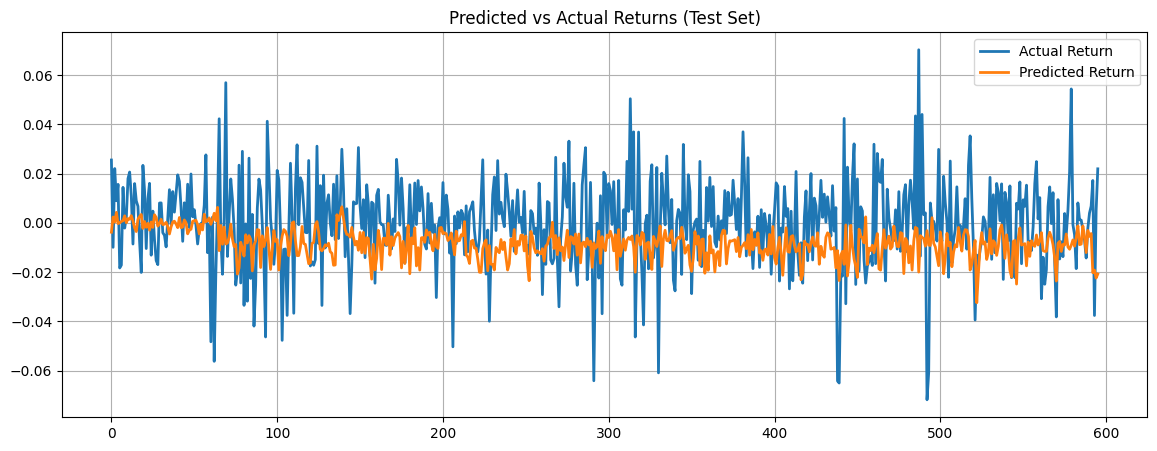

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.reset_index(drop=True), label="Actual Return", linewidth=2)
plt.plot(pred_ret_te, label="Predicted Return", linewidth=2)
plt.title("Predicted vs Actual Returns (Test Set)")
plt.legend()
plt.grid(True)
plt.show()


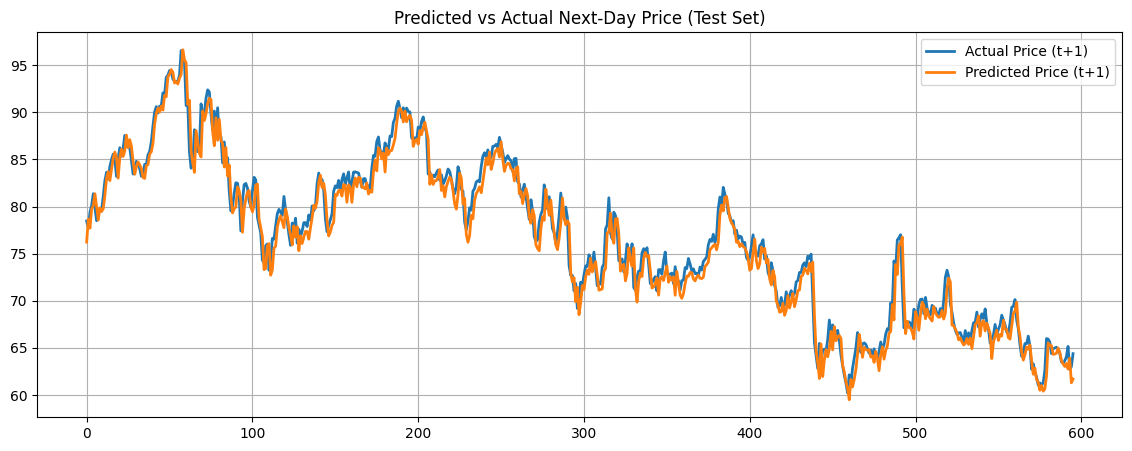

In [151]:
plt.figure(figsize=(14,5))
plt.plot(actual_price_te, label="Actual Price (t+1)", linewidth=2)
plt.plot(pred_price_te, label="Predicted Price (t+1)", linewidth=2)
plt.title("Predicted vs Actual Next-Day Price (Test Set)")
plt.legend()
plt.grid(True)
plt.show()


---

In [90]:
# Train stacking 입력
stack_train = pd.DataFrame({
    #"rf":     rf_res["pred_train"],
    #"gb":     gb_res["pred_train"],
    "lgbm":   lgbm_res["pred_train"],
    "cat":    cat_res["pred_train"],
    #"arima":  arima_pred_train,
}, index=y_train.index)

# Test stacking 입력
stack_test = pd.DataFrame({
    #"rf":     rf_res["pred_test"],
    #"gb":     gb_res["pred_test"],
    "lgbm":   lgbm_res["pred_test"],
    "cat":    cat_res["pred_test"],
    #"arima":  arima_pred_test,
}, index=y_test.index)


In [91]:
meta = CatBoostRegressor(
    depth=5,
    learning_rate=0.03,
    n_estimators=1000,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

meta.fit(stack_train, y_train)
meta_pred_train = meta.predict(stack_train)
meta_pred_test  = meta.predict(stack_test)


In [92]:
def evaluate_meta_model(name, y_train, pred_train, y_test, pred_test):
    # Train metrics
    rmse_tr = np.sqrt(mean_squared_error(y_train, pred_train))
    mae_tr  = mean_absolute_error(y_train, pred_train)
    mape_tr = calc_mape(y_train, pred_train)
    dir_tr  = directional_accuracy_return(y_train, pred_train)

    # Test metrics
    rmse_te = np.sqrt(mean_squared_error(y_test, pred_test))
    mae_te  = mean_absolute_error(y_test, pred_test)
    mape_te = calc_mape(y_test, pred_test)
    dir_te  = directional_accuracy_return(y_test, pred_test)

    print(f"\n[{name}]")
    print("Train - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_tr, mae_tr, mape_tr, dir_tr
    ))
    print("Test  - RMSE: {:.4f}, MAE: {:.4f}, MAPE: {:.2f}%, DirAcc: {:.3f}".format(
        rmse_te, mae_te, mape_te, dir_te
    ))


In [93]:
from sklearn.linear_model import Ridge

# 1) 베이스 모델 예측값 만들기
# rf_pred_train = rf.predict(X_train)
# rf_pred_test  = rf.predict(X_test)

# gb_pred_train = gb.predict(X_train)
# gb_pred_test  = gb.predict(X_test)

lgb_pred_train = lgbm.predict(X_train)
lgb_pred_test  = lgbm.predict(X_test)

cb_pred_train = cat.predict(X_train)
cb_pred_test  = cat.predict(X_test)

# ar_pred_train = arima_model.predict(X_train)
# ar_pred_test  = arima_model.predict(X_test)

# 2) 메타 모델 입력 행렬 만들기 (열 = 각 베이스 모델의 예측)
meta_X_train = np.vstack([
    #rf_pred_train,
    #gb_pred_train,
    lgb_pred_train,
    cb_pred_train
]).T  # shape: (n_train, 4)

meta_X_test = np.vstack([
    #rf_pred_test,
    #gb_pred_test,
    lgb_pred_test,
    cb_pred_test
]).T  # shape: (n_test, 4)

# 3) 메타 모델 학습 (Ridge 예시)
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(meta_X_train, y_train)

# 4) 메타 예측값
meta_pred_train = meta_model.predict(meta_X_train)
meta_pred_test  = meta_model.predict(meta_X_test)

# 5) 메타 모델 평가
evaluate_meta_model(
    "Stacking Meta Model",
    y_train,
    meta_pred_train,
    y_test,
    meta_pred_test
)



[Stacking Meta Model]
Train - RMSE: 0.0101, MAE: 0.0068, MAPE: 57.99%, DirAcc: 0.955
Test  - RMSE: 0.0282, MAE: 0.0238, MAPE: 544.79%, DirAcc: 0.510
